## 随机 filter 
核心内容：通过随机生成的滤波器（Filter/Kernel）对图像进行卷积操作。

教学目的：直观展示卷积核是如何提取图像特征（如边缘、纹理）的。 这是理解 CNN 的第一步，让你明白卷积层到底在处理什么。

In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, datasets
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

class myConvModel(keras.Model):
    def __init__(self):
        super(myConvModel, self).__init__()
        self.l1_conv = Conv2D(filters=3, kernel_size=(3, 3), padding='same')
        # 定义一个卷积层，3个卷积核（输出3个通道），3×3大小，same padding保持尺寸不变。
        # 权重是随机初始化的，没有训练，所以叫"random filter"

    @tf.function
    def call(self, x):
        h1 = self.l1_conv(x)
        # 前向传播，输入图片直接过一次卷积就输出
        return h1


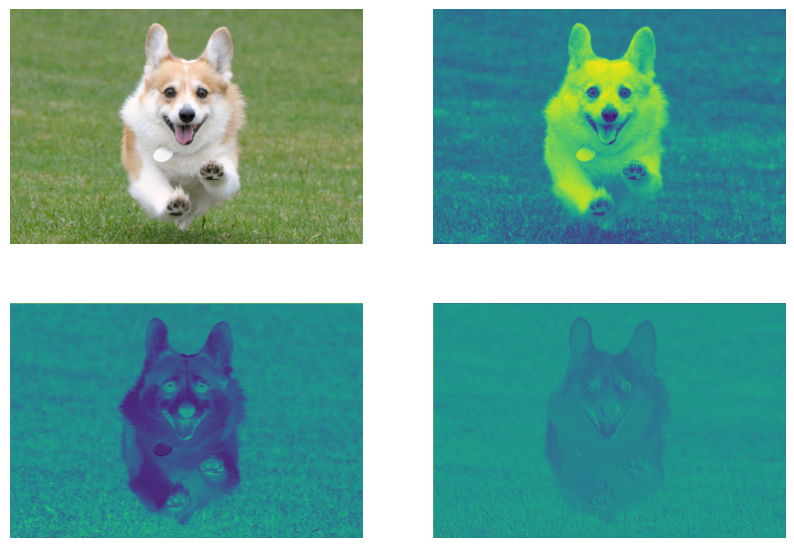

In [ ]:
random_conv = myConvModel()
import numpy
import pylab
from PIL import Image
import numpy as np

# open random image of dimensions 639x516
# 读取 corgi.jpg，转成 float 并归一化到 0~1，然后加一个 batch 维度，shape 变成 (1, H, W, 3)
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float64') / 256.
img = np.expand_dims(img, axis=0)
img_out = random_conv(img)

pylab.figure(figsize=(10,7))
# 把图片送进随机卷积模型，输出 shape 是 (1, H, W, 3)，即3个卷积核各产生一个特征图
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img[0, :, :, :])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2])
pylab.show()
